In [326]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    accuracy_score,           # subset accuracy = exact set match
    jaccard_score,
    multilabel_confusion_matrix,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import re
from math import isclose
import matplotlib.pyplot as plt

import json
import numpy as np
from pathlib import Path
import os

from tqdm import tqdm
import difflib
from sklearn.metrics import precision_score, recall_score, f1_score
from difflib import SequenceMatcher

tqdm.pandas()

In [327]:
import ast


In [332]:
ms_hermes = pd.read_csv("./data/ms_berger_sr/HERMES_INCLUDED_PMIDs_valid_title_annotated.csv")
ms_hermes = ms_hermes.rename(columns={'pmid':'PMID'})
ms_hermes = ms_hermes.drop(columns={'doi'})
ms_hermes = ms_hermes.fillna("not-reported")

def merge_tested_drugs(row):
    drugs = [
        str(row["Tested drug(s)"]).strip(),
        str(row["Tested drug 2"]).strip(),
        str(row["Tested drug 3"]).strip(),
    ]
    # Keep only valid entries (not 'not-reported', not empty, not NaN)
    valid = [d for d in drugs if d and d.lower() != "not-reported" and d.lower() != "nan"]
    return "|".join(valid) if valid else "not-reported"

ms_hermes["Tested drug(s)"] = ms_hermes.apply(merge_tested_drugs, axis=1)
ms_hermes = ms_hermes.drop(columns=["Tested drug 2", "Tested drug 3"])

ms_hermes.shape

(464, 12)

In [333]:
ms_hermes

,PMID,title,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals
0,27633171,Enterococcus faecium strain L-3 and glatiramer...,10.3920/bm2016.0018,EAE,rat,Wistar,female,12,Glatiramer acetate,control,1.0,122.0
1,24063549,Synergistic effects of atorvastatin and all-tr...,10.3109/08820139.2013.825269,EAE,mouse,C57BL/6,female,7,Atorvastatin,control,1.0,not-reported
2,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported
3,35496821,Loss of thymic function promotes EAE relapse i...,10.1016/j.crimmu.2022.03.001,EAE,mouse,C57BL/6 Foxp3-GFP,both,9,Alemtuzumab,control,1.0,not-reported
4,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0
...,...,...,...,...,...,...,...,...,...,...,...,...
459,31523122,Dimethyl fumarate mitigates optic neuritis,not-reported,EAE,mouse,C57BL/6,female,14,Dimethyl fumarate,control,1.0,not-reported
460,24045165,Cladribine interferes with IL-1β synaptic effe...,10.1016/j.jneuroim.2013.08.009,EAE,mouse,C57BL/6,female,8,Cladribine,control,1.0,48.0
461,90129,"The effect of COP 1, a synthetic polypeptide, ...",10.1016/0022-510x(79)90058-3,EAE,guinea pig,strain 13,not-reported,3,Glatiramer acetate,control,1.0,not-reported
462,12451183,Therapeutic intervention in experimental aller...,10.1073/pnas.212645999,EAE,mouse,PLSJL,female,9,Inosine,control,1.0,not-reported


In [334]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations.csv"
current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number']]
current_dataset['animal_sex'] = current_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))

/sctmp/sdonev/ipykernel_56969/3673949474.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number']]


## Check dataset coverage

In [335]:
def load_current_pmids():
    # All studies returned from the pubmed query
    all_original_pmids_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/01_pubmed_query_neuro/pmids_with_data.txt"
    with open(all_original_pmids_file) as f:
        all_query_pmids = set(map(int, filter(str.isdigit, f.read().splitlines())))
        
    # Predicted animal studies
    all_animal_studies = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/model_predictions/all_animal_studies_clean_complete.csv")

    # Identified as drug/disiease matching
    all_with_drug_disease = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_after_stype_filter_557138_PMIDs.csv")
    
    print(f"Original PMIDs: {len(all_query_pmids)}")
    print(f"Animal studies PMIDs: {len(all_animal_studies)}")
    print(f"Animal studies with DRUG and DISEASE PMIDs: {len(all_with_drug_disease)}")

    return all_query_pmids, all_animal_studies, all_with_drug_disease
    

In [336]:
all_query_pmids, all_animal_studies, all_with_drug_disease = load_current_pmids()

Original PMIDs: 21684927
Animal studies PMIDs: 6002827
Animal studies with DRUG and DISEASE PMIDs: 557138


In [337]:
target_pmids = set(ms_hermes.PMID)  # your list of PMIDs

In [338]:
def as_set(x, col="PMID"):
    if isinstance(x, (set, list, tuple)):
        return set(x)
    if isinstance(x, pd.Series):
        return set(x)
    if isinstance(x, pd.DataFrame):
        return set(x[col])
    raise TypeError("Unsupported type for PMIDs")

# Inputs (examples: adjust to your vars)
T = as_set(target_pmids)  # the PMIDs you want to keep through the whole pipeline
print(f"Target reference set length {len(T)}")
S_original = as_set(all_query_pmids)                 # after original query
S_animal   = as_set(all_animal_studies)              # after animal filter
S_ner      = as_set(all_with_drug_disease)           # after NER stage
S_fulltext = as_set(current_dataset)                 # after full text

stages = [
    ("Original query", S_original),
    ("Animal filter", S_animal),
    ("NER identified", S_ner),
    ("Full text", S_fulltext),
]

summary_rows = []
lost_ids_by_stage = {}

kept_prev = set(T)
for name, S in stages:
    kept_now = kept_prev & S
    lost_now = kept_prev - kept_now           # lost *at this stage*
    summary_rows.append({
        "stage": name,
        "kept_after_stage": len(kept_now),
        "lost_at_stage": len(lost_now),
        "cumulative_lost": len(T - kept_now),
        "remaining_fraction": f"{len(kept_now)/len(T):.1%}",
    })
    lost_ids_by_stage[name] = sorted(lost_now)
    kept_prev = kept_now                      # pass survivors to next stage

summary = pd.DataFrame(summary_rows)
print(summary)

# Optional: inspect which PMIDs were lost at each stage
# Example: show first few lost at each stage
for name in lost_ids_by_stage:
    print(f"\n{name} — lost {len(lost_ids_by_stage[name])}: {lost_ids_by_stage[name][:10]}")

Target reference set length 463
            stage  kept_after_stage  lost_at_stage  cumulative_lost  \
0  Original query               456              7                7   
1   Animal filter               442             14               21   
2  NER identified               427             15               36   
3       Full text               354             73              109   

  remaining_fraction  
0              98.5%  
1              95.5%  
2              92.2%  
3              76.5%  

Original query — lost 7: [21318047, 25729548, 26478898, 26587553, 26990079, 34944573, 35496821]

Animal filter — lost 14: [12402274, 15020068, 17906634, 19670379, 20348925, 23064699, 24076006, 24477403, 25712734, 26298324]

NER identified — lost 15: [14664472, 15494532, 17063394, 20308557, 21807883, 22056360, 22646698, 23276926, 27820602, 30065723]

Full text — lost 73: [1705564, 2413742, 2468392, 7529805, 7593550, 7594447, 7839818, 8574037, 8648142, 8759780]


In [339]:
# Sets
T  = set(ms_hermes["PMID"])                    # target set
S1 = set(all_query_pmids if isinstance(all_query_pmids, (set,list,tuple,pd.Series))
         else all_query_pmids["PMID"])
S2 = set(all_animal_studies["PMID"])
S3 = set(all_with_drug_disease["PMID"])
S4 = set(current_dataset["PMID"])              # full text

# Survivors right BEFORE full text
survivors_pre_fulltext = T & S1 & S2 & S3

# Stage "full text kept" (should be your 354)
stage_fulltext_kept = survivors_pre_fulltext & S4
print("Stage full-text kept:", len(stage_fulltext_kept))

# Make the merge reflect the same universe
ms_hermes_filtered = ms_hermes[ms_hermes["PMID"].isin(survivors_pre_fulltext)].drop_duplicates("PMID")
current_dataset_unique = current_dataset.drop_duplicates("PMID")

ms_hermes_joined = ms_hermes_filtered.merge(current_dataset_unique, on="PMID", how="inner")
print(f"After merge: {len(ms_hermes_joined)} rows ({ms_hermes_joined['PMID'].nunique()} unique PMIDs)")

# Identify the "extra" that made A∩F = 355 but stage = 354
extra_ids = (set(ms_hermes["PMID"]) & set(current_dataset["PMID"])) - stage_fulltext_kept
print("Extra IDs present in join but filtered earlier:", sorted(list(extra_ids))[:10])

Stage full-text kept: 354
After merge: 354 rows (354 unique PMIDs)
Extra IDs present in join but filtered earlier: [34849598]


In [340]:
current_dataset.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,rat,male,not reported,Sprague-Dawley,not reported
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,rabbit,not-reported,not reported,not reported,not reported
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin|Pentobarbital,rat,not-reported,not reported,not reported,2.0
4,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,beta-adrenergic receptor blocking agent|Nadolo...,"cat, dog",male,not reported,Mongrel,not reported


In [341]:
ms_hermes_joined.shape

(354, 20)

In [342]:
ms_hermes_joined.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals,title_y,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,"3 weeks, 8-10 weeks",C57BL/6,not reported
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma,VITAMIN D|Ergocalciferol,rat,female,"13 weeks, 3 weeks","Agouti,DA",not reported
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,1.0,not-reported,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon|Interferon beta (recombinant),mouse,female,8-10 weeks,C57BL/6,not reported
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,1.0,not-reported,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer",mouse,female,8-10 weeks,"C57BL/6,CBA/",not reported
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,1.0,not-reported,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"Acetate, Glatiramer|ga",mouse,female,8-12 weeks,"C57Bl,Sj",not reported


In [343]:
ms_hermes_joined = ms_hermes_joined.replace("not reported", "not-reported")


## Evaluate common entities

In [344]:
def eval_categorical(
    df: pd.DataFrame,
    target_col: str,
    pred_col: str,
    class_order=None,
    normalize=None,          # None | 'true' | 'pred' | 'all'
    dropna: bool = True,
    title: str = "Confusion Matrix",
    print_report: bool = True,
    id_col: str = "pmid",
    font_size: int = 15,      # 🔹 new: control label font size
    title_font_size: int = 15 # 🔹 new: control title font size
):
    """
    Evaluate categorical predictions with confusion matrix and return misclassified rows.
    Automatically scales figure size and allows control of label font sizes.
    """

    y_true = df[target_col]
    y_pred = df[pred_col]

    # Drop NA rows if requested
    if dropna:
        mask = y_true.notna() & y_pred.notna()
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        df = df.loc[mask]

    # Define class set
    if class_order is not None:
        classes = list(class_order)
    else:
        classes = sorted(pd.unique(pd.concat([y_true, y_pred], ignore_index=True)))

    if len(classes) == 0:
        raise ValueError("No classes found after filtering; check your inputs.")

    # Print classification report
    if print_report:
        print(classification_report(y_true, y_pred, labels=classes, zero_division=0, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize=normalize)
    values_format = None if normalize else "d"

    # 🔹 Dynamic figure size
    n_classes = len(classes)
    fig_size = max(6, n_classes * 0.6)
    plt.figure(figsize=(fig_size, fig_size))

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=values_format, ax=plt.gca(), colorbar=False)

    # 🔹 Customize fonts
    plt.title(title + (f" (normalized={normalize})" if normalize else ""), fontsize=title_font_size)
    plt.xlabel("Predicted label", fontsize=font_size)
    plt.ylabel("True label", fontsize=font_size)
    plt.xticks(rotation=45, ha="right", fontsize=font_size)
    plt.yticks(fontsize=font_size)

    # Optional: adjust annotation text size inside cells
    for text in plt.gca().texts:
        text.set_fontsize(font_size - 2)

    plt.tight_layout()
    plt.savefig(f"viz/{pred_col}_MS_study_conf_matrix.pdf")
    plt.show()
    

    # Identify mismatches
    mismatches = df[df[target_col] != df[pred_col]].copy()

    # Ensure id_col first
    if id_col in mismatches.columns:
        cols = [id_col] + [c for c in mismatches.columns if c != id_col]
        mismatches = mismatches[cols]

    # Return structured result
    return {
        "classes": classes,
        "confusion_matrix": cm,
        "mismatches": mismatches[[id_col, target_col, pred_col]]
        if id_col in mismatches.columns
        else mismatches[[target_col, pred_col]],
    }

In [345]:
df = ms_hermes_joined.copy()

              precision    recall  f1-score   support

        both      0.783     0.562     0.655        32
      female      0.970     0.938     0.954       242
        male      0.783     0.973     0.867        37
not-reported      0.725     0.860     0.787        43

    accuracy                          0.898       354
   macro avg      0.815     0.833     0.816       354
weighted avg      0.904     0.898     0.897       354



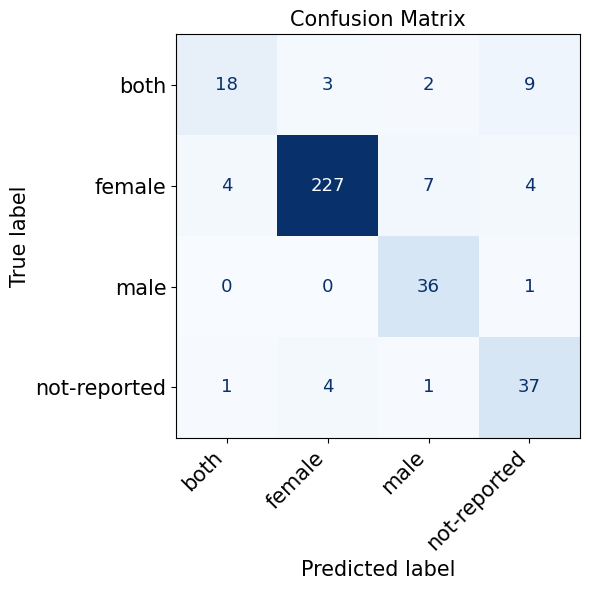

In [346]:
res = eval_categorical(
    df,
    target_col="Sex",
    pred_col="animal_sex",
    id_col="pmid"
)

res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/sex_mismatches.csv")

                        precision    recall  f1-score   support

            cat, mouse      0.000     0.000     0.000         0
              cat, rat      0.000     0.000     0.000         0
       dog, mouse, rat      0.000     0.000     0.000         0
            guinea pig      1.000     1.000     1.000         1
guinea pig, mouse, rat      0.000     0.000     0.000         0
                monkey      1.000     1.000     1.000         2
                 mouse      0.996     0.934     0.964       286
            mouse, rat      0.000     0.000     0.000         0
        mouse, xenopus      0.000     0.000     0.000         1
                   rat      1.000     0.905     0.950        63
         species-other      0.000     0.000     0.000         0
             zebrafish      0.000     0.000     0.000         1

              accuracy                          0.924       354
             macro avg      0.333     0.320     0.326       354
          weighted avg      0.991     

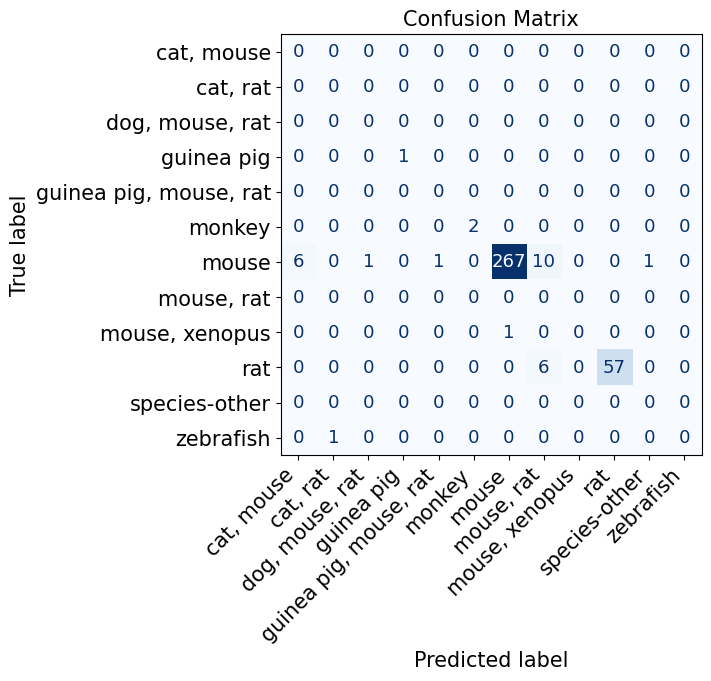

In [18]:
df["Species"] = df["Species"].replace("marmoset", "monkey")

res = eval_categorical(
    df,
    target_col="Species",
    pred_col="animal_species",
    id_col="pmid"
)
res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/species_mismatches.csv")

In [19]:
def evaluate_multilabel_sets(
    df: pd.DataFrame,
    true_col: str,
    pred_col: str,
    sep: str = ",",
    class_order: list[str] | None = None,
    show_per_class_report: bool = True,
    plot_per_class_confmat: bool = False,
    extra_cols: list[str] | None = None,   # e.g., ["pmid"]
    id_col: str | None = None              # e.g., "pmid"
):
    # --- helpers ---
    def _normalize(s: str) -> str:
        return s.strip().lower()

    def _split_set(x, sep=","):
        if pd.isna(x):
            return set()
        parts = [p for p in str(x).split(sep)]
        return {_normalize(p) for p in parts if _normalize(p)}

    # Resolve a column or index (case-insensitive); if not found and name == 'pmid',
    # fall back to using the index values and name it 'pmid'.
    colmap = {c.lower(): c for c in df.columns}
    def _get_series(name: str):
        if name is None:
            return None
        # exact column
        if name in df.columns:
            return df[name]
        # case-insensitive column
        low = name.lower()
        if low in colmap:
            return df[colmap[low]]
        # index name match (case-insensitive)
        if df.index.name and df.index.name.lower() == low:
            return pd.Series(df.index, index=df.index, name=df.index.name)
        # final fallback for 'pmid': use index even if unnamed
        if low == "pmid":
            return pd.Series(df.index, index=df.index, name="pmid")
        return None

    # Parse to sets
    y_true_sets = df[true_col].map(lambda x: _split_set(x, sep))
    y_pred_sets = df[pred_col].map(lambda x: _split_set(x, sep))

    # Row-level counts
    n_true = y_true_sets.map(len)
    n_pred = y_pred_sets.map(len)

    # Any-overlap & exact-set match
    any_overlap = pd.Series([(len(t & p) > 0) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)
    exact_match = pd.Series([(t == p) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)

    # Label universe
    if class_order is None:
        all_labels = sorted(set().union(*y_true_sets, *y_pred_sets))
    else:
        all_labels = list(class_order)

    # Binarize
    mlb = MultiLabelBinarizer(classes=all_labels)
    Y_true = mlb.fit_transform(y_true_sets)
    Y_pred = mlb.transform(y_pred_sets)

    # Metrics
    subset_acc = accuracy_score(Y_true, Y_pred)
    jaccard_samples = jaccard_score(Y_true, Y_pred, average="samples") if len(df) else 0.0
    prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="micro", zero_division=0)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(Y_true, Y_pred, average="weighted", zero_division=0)

    class_report = None
    if show_per_class_report and len(all_labels) > 0:
        class_report = classification_report(Y_true, Y_pred, target_names=all_labels, zero_division=0, digits=3)

    per_class_conf = multilabel_confusion_matrix(Y_true, Y_pred, labels=range(len(all_labels)))

    stats = {
        "total_rows": int(len(df)),
        "any_overlap_accuracy": float(any_overlap.mean()) if len(df) else 0.0,
        "exact_match_accuracy": float(subset_acc),
        "jaccard_samples": float(jaccard_samples),
        "num_multi_pred": int((n_pred > 1).sum()),
        "rate_multi_pred": float((n_pred > 1).mean()) if len(df) else 0.0,
        "num_single_pred": int((n_pred == 1).sum()),
        "num_zero_pred": int((n_pred == 0).sum()),
        "num_multi_true": int((n_true > 1).sum()),
        "rate_multi_true": float((n_true > 1).mean()) if len(df) else 0.0,
        "precision_micro": float(prec_micro),
        "recall_micro": float(rec_micro),
        "f1_micro": float(f1_micro),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "labels": all_labels,
    }

    # --- per-row overview (include extras + robust id handling) ---
    cols = {
        "true_raw": df[true_col],
        "pred_raw": df[pred_col],
        "true_set": y_true_sets,
        "pred_set": y_pred_sets,
        "n_true": n_true,
        "n_pred": n_pred,
        "any_overlap_correct": any_overlap,
        "exact_match": exact_match,
    }

    # Add extra columns (case-insensitive; column or index; pmid fallback)
    if extra_cols:
        for c in extra_cols:
            s = _get_series(c)
            if s is not None:
                cols[c] = s

    per_row = pd.DataFrame(cols)

    # Ensure id_col exists, then move first and set as index (keeping the column)
    if id_col:
        s = _get_series(id_col)
        if s is not None:
            per_row[id_col] = s
        if id_col in per_row.columns:
            ordered = [id_col] + [c for c in per_row.columns if c != id_col]
            per_row = per_row[ordered].set_index(id_col, drop=False)  # change to drop=True if you only want it as index

    if class_report:
        print(class_report)

    return stats, per_row, per_class_conf

In [20]:
df = ms_hermes_joined.copy()
df.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals,title_y,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,"3 weeks, 8-10 weeks",C57BL/6,not-reported
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma,VITAMIN D|Ergocalciferol,rat,female,"13 weeks, 3 weeks","Agouti,DA",not-reported
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,1.0,not-reported,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon|Interferon beta (recombinant),mouse,female,8-10 weeks,C57BL/6,not-reported
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,1.0,not-reported,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer",mouse,female,8-10 weeks,"C57BL/6,CBA/",not-reported
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,1.0,not-reported,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"Acetate, Glatiramer|ga",mouse,female,8-12 weeks,"C57Bl,Sj",not-reported


In [21]:
import sys
from pathlib import Path

# In Jupyter, use the current working directory
CWD = Path().resolve()
TARGET_DIR = CWD.parent / "08_IE_full_text"

sys.path.insert(0, str(TARGET_DIR))

from map_strain_values import (
    build_lookup_table,
    normalize_animal_strains,
    postprocess_family_level
)

In [22]:
synonyms_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/data/strain_normalization/combined_df_mice_rat.csv"
column = "Strain"
new_column = "Target_animal_strain_norm"
delimiter = ","
post_column = "Target_animal_strain_norm_family"

print(f"Loading synonym lookup from: {synonyms_file}")
canonical_lookup = build_lookup_table(synonyms_file)

# Normalize (fuzzy/synonym)
print(f"Normalizing strain names in column: {column}")
df = normalize_animal_strains(
    df,
    canonical_lookup,
    column=column,
    new_column=new_column,
    delimiter=delimiter,
)

# Post-process to family-level generic forms
post_col = post_column or f"{new_column}_family"
print(f"Post-processing to family-level in column: {post_col}")
df[post_col] = df[new_column].progress_apply(lambda x: postprocess_family_level(x, delimiter))



Loading synonym lookup from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/data/strain_normalization/combined_df_mice_rat.csv
Normalizing strain names in column: Strain


100%|██████████| 354/354 [00:01<00:00, 332.98it/s]


Post-processing to family-level in column: Target_animal_strain_norm_family


100%|██████████| 354/354 [00:00<00:00, 60894.21it/s]


In [23]:
df = df.replace("notreported", "not-reported")


In [24]:
df.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,title_y,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number,Target_animal_strain_norm,Target_animal_strain_norm_family
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,...,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,"3 weeks, 8-10 weeks",C57BL/6,not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,...,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma,VITAMIN D|Ergocalciferol,rat,female,"13 weeks, 3 weeks","Agouti,DA",not-reported,DA,DA
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,...,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon|Interferon beta (recombinant),mouse,female,8-10 weeks,C57BL/6,not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,...,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer",mouse,female,8-10 weeks,"C57BL/6,CBA/",not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,...,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"Acetate, Glatiramer|ga",mouse,female,8-12 weeks,"C57Bl,Sj",not-reported,"C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,(SJLxBAL...","C57BL/6,F1"


In [25]:
stats, per_row, per_class = evaluate_multilabel_sets(
    df,
    true_col="Target_animal_strain_norm_family",
    pred_col="animal_strain",
    sep=",",
    extra_cols=["pmid"],   # include pmid in the overview
    id_col="pmid"          # show pmid as the index/first column
)

print(stats["any_overlap_accuracy"])


                           precision    recall  f1-score   support

                       1s      0.000     0.000     0.000         0
                       2b      0.000     0.000     0.000         0
                       2d      0.000     0.000     0.000         0
                      2d2      0.000     0.000     0.000         0
                     2d2t      0.000     0.000     0.000         0
                      abc      0.000     0.000     0.000         0
                    agout      0.000     0.000     0.000         0
                   agouti      0.000     0.000     0.000         0
                      b10      0.000     0.000     0.000         0
         b10d1ih2supq/sup      0.000     0.000     0.000         0
                    b10pl      0.000     0.000     0.000         0
b10plih2supu/suph2t18supa      0.571     0.800     0.667        10
                    b10ri      0.000     0.000     0.000         0
                  b10riii      1.000     1.000     1.000     

In [26]:
# Peek at rows with mismatches, but include pmid:
per_row[~per_row["any_overlap_correct"]].to_csv("./outputs/ms_hermes_annotations_validation/strain_mismatches.csv")
per_row[~per_row["any_overlap_correct"]].head()

,pmid,true_raw,pred_raw,true_set,pred_set,n_true,n_pred,any_overlap_correct,exact_match
pmid,,,,,,,,,
16365293,16365293,"C57BL/6,F1","C57Bl,Sj","{c57bl/6, f1}","{sj, c57bl}",2,2,False,False
12020957,12020957,F1,SjlJ,{f1},{sjlj},1,1,False,False
21752599,21752599,F1,"C57BL/6,SJL",{f1},"{c57bl/6, sjl}",1,2,False,False
21459808,21459808,BiozziABH,not-reported,{biozziabh},{not-reported},1,1,False,False
22547654,22547654,not-reported,BALB/C,{not-reported},{balb/c},1,1,False,False


In [27]:
import unicodedata

def normalize_text(s):
    if isinstance(s, str):
        s = unicodedata.normalize("NFKC", s.strip().lower())
        s = s.replace("‐", "-")  # replace Unicode hyphen with ASCII
    return s

df["Total number of animals"] = df["Total number of animals"].apply(normalize_text)
df["animal_number"] = df["animal_number"].apply(normalize_text)

In [28]:
def eval_animal_number(
    df,
    true_col="Total number of animals",
    pred_col="animal_number",
    atol=1e-9
):
    """
    Evaluates numeric predictions vs. true totals.
    exact_match = single prediction == true
    partial_match = true in predictions AND more than one prediction
    """
    def parse_preds(val):
        if pd.isna(val):
            return []
        if isinstance(val, (list, tuple, np.ndarray)):
            return [float(v) for v in val if pd.notna(v)]
        if isinstance(val, str):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, (list, tuple)):
                    return [float(v) for v in parsed]
                else:
                    return [float(parsed)]
            except Exception:
                nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', val)
                return [float(n) for n in nums] if nums else []
        try:
            return [float(val)]
        except Exception:
            return []

    rows = []
    for _, r in df.iterrows():
        true_val = float(r[true_col])
        raw_pred = r[pred_col]
        preds = parse_preds(raw_pred)

        best_pred = np.nan
        abs_error = np.nan
        rel_error = np.nan
        exact_match = False
        partial_match = False
        contains_true = any(isclose(p, true_val, abs_tol=atol) for p in preds)

        if preds:
            errors = [abs(p - true_val) for p in preds]
            j = int(np.argmin(errors))
            best_pred = preds[j]
            abs_error = errors[j]
            rel_error = abs_error / true_val if true_val else np.nan

            if contains_true:
                if len(preds) == 1:
                    exact_match = True
                elif len(preds) > 1:
                    partial_match = True

        # others relative to true
        others = [p for p in preds if not isclose(p, true_val, abs_tol=atol)]
        other_preds_below_true = [p for p in others if p < true_val] or None
        other_preds_above_true = [p for p in others if p > true_val] or None

        rows.append({
            "true": true_val,
            "pred_raw": raw_pred,
            "best_pred": best_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "exact_match": exact_match,
            "partial_match": partial_match,
            "other_preds_below_true": other_preds_below_true,
            "other_preds_above_true": other_preds_above_true,
        })

    per_row = pd.DataFrame(rows)

    summary = {
        "n": len(per_row),
        "n_exact_match": int(per_row["exact_match"].sum()),
        "exact_match_rate": per_row["exact_match"].mean(),
        "n_partial_match": int(per_row["partial_match"].sum()),
        "partial_match_rate": per_row["partial_match"].mean(),
        "mean_abs_error": per_row["abs_error"].mean(),
        "median_abs_error": per_row["abs_error"].median(),
        "mean_rel_error": per_row["rel_error"].mean(),
    }

    return summary, per_row

In [29]:
def extract_max_animal_number(val):
    # Handle missing values
    if pd.isna(val):
        return None
    
    # Case 1: actual Python list
    if isinstance(val, (list, tuple)):
        return max(val)
    
    # Case 2: string like "[10, 12,30]"
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple)) and all(isinstance(x, (int, float)) for x in parsed):
                return max(parsed)
        except Exception:
            pass  # Not a valid list string
        
        # If it's just a single number string like "15"
        try:
            return float(val)
        except ValueError:
            return None
    
    return None

In [30]:
def to_number(val):
    """Convert value to number, return 0 for non-numeric or 'not-reported'."""
    if pd.isna(val):
        return 0
    if isinstance(val, (int, float)):
        return val
    val = str(val).strip().lower()
    if val in ["not-reported", "not reported", "na", "nan", "none", ""]:
        return 0
    try:
        return float(val)
    except ValueError:
        return 0

# Apply conversion
ms_hermes_joined["Total number of animals (num)"] = ms_hermes_joined["Total number of animals"].apply(to_number)

# Get total sum
total_animals = ms_hermes_joined["Total number of animals (num)"].sum()

print(f"Total number of animals across dataset: {int(total_animals)}")

Total number of animals across dataset: 6696


In [31]:
len(ms_hermes_joined[ms_hermes_joined["Total number of animals"]!= "not-reported"])

113

In [32]:
len(ms_hermes_joined[ms_hermes_joined["animal_number"]!= "not-reported"])

62

In [33]:
ms_hermes_joined["animal_number_max"] = ms_hermes_joined["animal_number"].apply(extract_max_animal_number)

# Apply conversion
ms_hermes_joined["Total predicted number of animals (num)"] = ms_hermes_joined["animal_number_max"].apply(to_number)

# Get total sum
total_animals_predicted = ms_hermes_joined["Total predicted number of animals (num)"].sum()

print(f"Total number of animals across dataset: {int(total_animals_predicted)}")

Total number of animals across dataset: 4619


In [34]:
filtered_animal_nr_both_labeled = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] != "not-reported")
]

In [35]:
filtered_animal_nr_both_labeled.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number,Total number of animals (num),animal_number_max,Total predicted number of animals (num)
18,36688131,Therapeutic effect of combination vitamin D3 a...,10.3389/fnbeh.2022.1068736,cuprizone,mouse,SWR/J,male,6.5,Vitamin D3,control,...,multiple sclerosis,sipo|vitamin D3|siponimod|Cholecalciferol,mouse,male,6-7 weeks,"Swiss,SWR",85.0,85.0,85.0,85.0
19,26198937,Fingolimod does not enhance cerebellar remyeli...,10.1016/j.jneuroim.2015.06.006,cuprizone,mouse,C57BL/6,female,5,Fingolimod,control,...,relapsing-remitting multiple sclerosis|multipl...,Fingolimod|fty720-c2,mouse,female,5 weeks,C57BL/6,32.0,32.0,32.0,32.0
36,30524355,Regular Exercise Modifies Histopathological Ou...,10.3389/fneur.2018.00950,EAE,mouse,C57BL/6,female,5,"Dimethyl fumarate, Glatiramer acetate",control,...,multiple sclerosis,"Acetate, Glatiramer|Fumarate, Dimethyl",mouse,female,4-6 weeks,C57BL/6,96.0,96.0,96.0,96.0
41,21615449,Glatiramer acetate-specific antibody titres in...,10.1111/j.1365-3083.2011.02581.x,EAE,mouse,C57BL/6,female,7,Glatiramer acetate,control,...,relapsing-remitting multiple sclerosis|clinica...,"Acetate, Glatiramer",mouse,female,6-8 weeks,C57BL/6,12.0,12.0,12.0,12.0
44,9394786,"Synergism between sirolimus and 1,25-dihydroxy...",10.1016/s0165-5728(97)00116-1,EAE,mouse,SJL,male,9,Vitamin D3,control,...,multiple sclerosis,"1,25-dihydroxyvitamin D|dihydroxy-vitamin D3|d...",mouse,male,not-reported,"NMRI,SJL",308.0,308.0,308.0,308.0


In [36]:
summary, details = eval_animal_number(filtered_animal_nr_both_labeled,
                                      true_col="Total number of animals",
                                      pred_col="animal_number_max")

print(summary)
print(details.head())

{'n': 51, 'n_exact_match': 45, 'exact_match_rate': 0.8823529411764706, 'n_partial_match': 0, 'partial_match_rate': 0.0, 'mean_abs_error': 2.784313725490196, 'median_abs_error': 0.0, 'mean_rel_error': 0.04910241623044391}
    true  pred_raw  best_pred  abs_error  rel_error  exact_match  \
0   85.0      85.0       85.0        0.0        0.0         True   
1   32.0      32.0       32.0        0.0        0.0         True   
2   96.0      96.0       96.0        0.0        0.0         True   
3   12.0      12.0       12.0        0.0        0.0         True   
4  308.0     308.0      308.0        0.0        0.0         True   

   partial_match other_preds_below_true other_preds_above_true  
0          False                   None                   None  
1          False                   None                   None  
2          False                   None                   None  
3          False                   None                   None  
4          False                   None      

In [37]:
details.to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions.csv", index=False)

In [38]:
details.head()

,true,pred_raw,best_pred,abs_error,rel_error,exact_match,partial_match,other_preds_below_true,other_preds_above_true
0,85.0,85.0,85.0,0.0,0.0,True,False,None,None
1,32.0,32.0,32.0,0.0,0.0,True,False,None,None
2,96.0,96.0,96.0,0.0,0.0,True,False,None,None
3,12.0,12.0,12.0,0.0,0.0,True,False,None,None
4,308.0,308.0,308.0,0.0,0.0,True,False,None,None


In [39]:
filtered_animal_nr_pred_only = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] == "not-reported") &
    (ms_hermes_joined["animal_number"] != "not-reported")
]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FP.csv",index=False)

In [40]:
filtered_animal_nr_pred_only.shape

(11, 23)

In [41]:
filtered_animal_nr_pred_missing = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] == "not-reported")
]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FN.csv",index=False)

In [42]:
filtered_animal_nr_pred_missing.shape

(62, 23)

### drug

In [68]:
from transformers import AutoTokenizer, AutoModel


In [347]:
ms_hermes_joined_drugs = ms_hermes_joined[['PMID','Tested drug(s)','drug_term_umls_norm']]

In [348]:
CURRENT_DIR = Path().resolve()
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))

from neural_based_nen import map_query_to_terminology

In [349]:
CURRENT_DIR = Path().resolve().parent
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))
from neural_based_nen import map_query_to_terminology

TERMINOLOGY = "umls"
DIST_THRESHOLD = 7.8
EMBEDDINGS_DIR = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/embeddings"
BATCH_PREFIX = "UMLS_emb"
TERM_ID_FILE = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/umls_term_id_pairs.json"
ID_TO_TERM_MAP = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/{TERMINOLOGY}_id_to_term_map.json"

# --- Load embeddings ---
embedding_files = sorted([
    os.path.join(EMBEDDINGS_DIR, f) for f in os.listdir(EMBEDDINGS_DIR)
    if f.startswith(f"{BATCH_PREFIX}_batch_") and f.endswith(".npy")
])
all_embeddings = [np.load(f) for f in embedding_files]
embeddings_to_use = np.concatenate(all_embeddings, axis=0)

# --- Load mapping and metadata ---
with open(TERM_ID_FILE, "r") as f:
    corresponding_term_id = json.load(f)

with open(ID_TO_TERM_MAP, "r", encoding="utf-8") as f:
    canonical_mapping_dict = json.load(f)

# --- Load model ---
tokenizer = AutoTokenizer.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")
model = AutoModel.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")



/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [350]:
query = "vitamin D" # fingolimod-1 phosphate, fty720-c2
predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
        query,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
nearest_3, canonical_form

([['VITAMIN D', 'C3714503'],
  ['Vitamin D', 'C0042866'],
  ['CALCIUM/VITAMIN D', 'C0719107'],
  ['VITAMIN D,OTHER', 'C1875862'],
  ['vitamin D3', 'C3265062']],
 'VITAMIN D')

In [351]:
def normalize_tested_drugs_cell(
    cell: str,
    tokenizer,
    model,
    embeddings_to_use,
    corresponding_term_id,
    canonical_mapping_dict,
    dist_threshold: float
) -> str:
    """
    Normalize a comma-separated string of drugs into a '|' separated string of canonical names.
    - Keeps original term when map_query_to_terminology returns -1 (your function already does that).
    - Deduplicates while preserving order.
    - Handles NaN / empty cells gracefully.
    """
    if pd.isna(cell) or not isinstance(cell, str):
        return ""

    # Split by commas or | sign (tolerate extra spaces); ignore empty chunks
    parts = [p.strip() for p in re.split(r"\s*[|,]\s*", str(cell)) if p.strip()]

    if not parts:
        return ""

    canonicals = []
    seen = set()
    for query in parts:
        predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
            query,
            tokenizer,
            model,
            embeddings_to_use,
            corresponding_term_id,
            canonical_mapping_dict,
            dist_threshold=dist_threshold
        )
        # Use canonical_form (your function already falls back to original query if no mapping)
        if canonical_form not in seen:
            seen.add(canonical_form)
            canonicals.append(canonical_form)

    # Join canonicals with pipe
    return "|".join(canonicals)



In [352]:
# Apply to your DataFrame
# Assumes you already have: tokenizer, model, embeddings_to_use, corresponding_term_id, canonical_mapping_dict, DIST_THRESHOLD
ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(
    lambda cell: normalize_tested_drugs_cell(
        cell,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
)

100%|██████████| 354/354 [02:39<00:00,  2.22it/s]
/sctmp/sdonev/ipykernel_56969/2574029870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(


In [ ]:
ms_hermes_joined_drugs

In [353]:
ms_hermes_joined_drugs[ms_hermes_joined_drugs["Tested drug(s)"].astype(str).str.contains(r"\|")]

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target
15,32214838,Rituximab|Monomethyl fumarate,riTUXimab,riTUXimab|Monomethyl fumarate
17,26580651,Vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin...",vitamin D3|Monomethyl fumarate
18,36688131,Vitamin D3|Siponimod,sipo|vitamin D3|siponimod|Cholecalciferol,vitamin D3|siponimod
20,25493280,Rituximab|Fingolimod,CD20Bi antibody|CD20Bi antibody|fty720-c2|Anti...,riTUXimab|Fingolimod
27,11160259,Estriol|Estriol,Estriol|Estradiol|Estrogens,Estriol
64,20955831,Fingolimod|Interferon Beta 1,sphingosine 1-phosphate receptor modulator|rm-...,Fingolimod|beta 1 Interferon
74,26692368,Fingolimod|Dimethyl fumarate,"Fumarate, Dimethyl|Fingolimod|Fumarate, Dimeth...","Fingolimod|Fumarate, Dimethyl"
78,32293668,Fampridine|Fingolimod,Dalfampridine|Aminopyridine|Fingolimod,Fampridine|Fingolimod
87,27718209,Natalizumab|Dimethyl fumarate,"Natalizumab|Fumarate, Dimethyl|Acetylcysteine","Natalizumab|Fumarate, Dimethyl"
105,15958276,Minocycline|Interferon Beta 1,Interferon beta (recombinant)|Minocycline,Minocycline|beta 1 Interferon


In [354]:
ms_hermes_joined_drugs.to_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df.csv",index=False)

#### start here if drugs already mapped

In [355]:
def compute_annotations(row, entity, model, pred_column):

    target_col = f'unique_{entity.replace("_v1","").replace("_v2","")}_target'
    model_col = pred_column #"drug_term_umls_norm"#f'unique_{entity}_{model}'
    
    target_entities = (
        [] if pd.isna(row[target_col]) or str(row[target_col]).strip() == ""
        else str(row[target_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    target_entities = [e for e in target_entities if len(e) > 2]

    predicted_entities = (
        [] if pd.isna(row[model_col]) or str(row[model_col]).strip() == ""
        else str(row[model_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    predicted_entities = [e for e in predicted_entities if len(e) > 2]

    if not target_entities or not predicted_entities:
        return handle_empty_arrays(target_entities, predicted_entities)

    # Create a set of all unique entities from both target and predicted for consistent indexing
    all_entities = set(target_entities + predicted_entities)

    # Target annotations (exact)
    target_annotations_exact = [1 if entity in target_entities else 0 for entity in all_entities]

    # Predicted annotations (exact)
    predicted_annotations_exact = [1 if entity in predicted_entities else 0 for entity in all_entities]

    # Target annotations (partial)
    target_annotations_partial = [1 if any(partial_match(entity, target_ent) for target_ent in target_entities) else 0 for entity in all_entities]

    # Predicted annotations (partial)
    predicted_annotations_partial = [1 if any(partial_match(entity, pred) for pred in predicted_entities) else 0 for entity in all_entities]

    return pd.Series([
        target_annotations_exact,
        predicted_annotations_exact,
        target_annotations_partial,
        predicted_annotations_partial
    ], index=[
        f'target_{entity}_annotations_exact_{model}',
        f'predicted_{entity}_annotations_exact_{model}',
        f'target_{entity}_annotations_partial_{model}',
        f'predicted_{entity}_annotations_partial_{model}'
    ])

In [356]:
def partial_match_simple(predicted, target):
    predicted_parts = predicted.lower().split()
    target_parts = target.lower().split()
    return any(pred_part in target_part or target_part in pred_part for pred_part in predicted_parts for target_part in target_parts)

# Function to check for partial matches using difflib
def partial_match(predicted, target, cutoff=0.6):
    # Split the conditions into individual terms
    predicted_terms = predicted.split('|')
    target_terms = target.split('|')
    
    # Check for matches across all terms
    matches = []
    for pred in predicted_terms:
        # Use difflib to find close matches, with a cutoff for match quality
        match_found = any(difflib.get_close_matches(pred, target_terms, n=1, cutoff=cutoff))
        matches.append(match_found)
    
    # Return True if any match is found
    return any(matches)

def handle_empty_arrays(target_entities, predicted_entities):
    # Construct the results based on whether target_entities or predicted_entities are empty
    if target_entities == [''] and predicted_entities == ['']:
        return pd.Series([
            [0],  # No target entities to match against, so exact match is [0]
            [0],  # No predicted entities to match against, so exact match is [0]
            [0],  # No target entities for partial matches, so partial match is [0]
            [0]   # No predicted entities for partial matches, so partial match is [0]
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    elif target_entities == ['']:
        return pd.Series([
            [0] * len(predicted_entities),  
            [1] * len(predicted_entities),  
            [0] * len(predicted_entities), 
            [1] * len(predicted_entities)  
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    # Handle case where predicted_entities is empty, if required
    else: # predicted_entities == ['']:
        return pd.Series([
            [1] * len(target_entities), 
            [0] * len(target_entities),  
            [1] * len(target_entities),  
            [0] * len(target_entities)   
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
        
def flatten_column_arrays(column):
    # Prepare an array to hold the actual arrays/lists
    prepared_arrays = []
    
    for item in column:
        if isinstance(item, str):
            try:
                # Safely evaluate the string to see if it represents a list
                evaluated_item = ast.literal_eval(item)
                if isinstance(evaluated_item, list):
                    prepared_arrays.append(np.array(evaluated_item))
            except (SyntaxError, ValueError):
                # If evaluation fails or it's not a list, skip or handle non-list string
                print("Not possible to flatten ", item)
                continue
        elif isinstance(item, list):
            prepared_arrays.append(np.array(item))
        elif isinstance(item, np.ndarray):
            prepared_test_arrays.append(item)
    
    if prepared_arrays:
        # Concatenate all arrays in the list and then flatten the result
        return np.concatenate(prepared_arrays).flatten()
    else:
        return np.array([])  # Return an empty array if no valid arrays were found

def round_tuple(x, decimals=2):
    """
    Recursively round elements of a tuple.
    If x is a scalar (int/float), return the rounded value directly.
    """
    if isinstance(x, (int, float)):
        return round(x, decimals)
    elif isinstance(x, tuple):
        return tuple(round_tuple(item, decimals) for item in x)
    else:
        raise TypeError(f"Unsupported type {type(x)} for round_tuple")
        
def calculate_exact_and_partial_match_scores(annotations_df, entities, models, round_to=2):
    exact_matches = {}
    partial_matches = {}
    scores = {}
    for entity in entities:
        exact_matches[entity] = {}
        partial_matches[entity] = {}
        scores[entity] = {}
    
        for model in models:
            if (entity != 'condition' and entity != 'drug') and 'regex' in model:
               continue  
            #try:
            # Check if all columns are present in the DataFrame
            # Columns to check
            columns_to_check = [f'target_{entity}_annotations_exact_{model}',
                                f'predicted_{entity}_annotations_exact_{model}',
                                f'target_{entity}_annotations_partial_{model}',
                                f'predicted_{entity}_annotations_partial_{model}']
            
            # Check if all columns are present in the DataFrame
            missing_columns = [col for col in columns_to_check if col not in annotations_df.columns]
            if not missing_columns:
                flattened_data_target_exact = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_exact_{model}'])
                flattened_data_model_exact = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_exact_{model}'])
                flattened_data_target_partial = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_partial_{model}'])
                flattened_data_model_partial = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_partial_{model}'])
            else:
                # Handle the case where one or more columns are missing
                print("The following required columns are missing in the DataFrame:")
                for col in missing_columns:
                    print(col)
    
            flattened_data_target_exact = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_model_exact = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_target_partial = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_partial_{model}', pd.Series()))
            flattened_data_model_partial = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_partial_{model}', pd.Series()))

            # Calculate and store F1 scores
            exact_f1 = f1_score(flattened_data_target_exact, flattened_data_model_exact, average='binary')
            print(exact_f1)
            partial_f1 = f1_score(flattened_data_target_partial, flattened_data_model_partial, average='binary')

            exact_precision = precision_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_precision = precision_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_recall = recall_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_recall = recall_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_matches[entity][model] = round_tuple(exact_f1,round_to)
            partial_matches[entity][model] = round_tuple(partial_f1,round_to)

            scores[entity][model] = {
                "exact": {
                    "precision": round_tuple(exact_precision, round_to),
                    "recall": round_tuple(exact_recall, round_to),
                    "f1": round_tuple(exact_f1, round_to),
                },
                "partial": {
                    "precision": round_tuple(partial_precision, round_to),
                    "recall": round_tuple(partial_recall, round_to),
                    "f1": round_tuple(partial_f1, round_to),
                }
            }
    
           # except Exception as e:
            #    print(f"An error occurred for {model} in {entity}: {e}")
    return exact_matches, partial_matches, scores

In [357]:
def clean_predictions(drugs_list):
    drug_names = drugs_list.split("|")
    drug_names_clean = set()
    for drug_name in drug_names:
        if any(word in drug_name.lower() for word in ["antibody", "receptor", "anibodies", "modulator", "blocker", "antagonis", "anti-", "inhibitor"]):
            continue
        elif drug_name == "fty720-c2" or (drug_name == "fingolimod-1 phosphate"):
            drug_name = "Fingolimod"
        elif drug_name == "1,25-dihydroxyvitamin D" or (drug_name == "1alpha,25-dihydroxyvitamin D") or (drug_name == "Calcitriol") or (drug_name == "Cholecalciferol"):
            drug_name = "vitamin D3"
        drug_names_clean.add(drug_name)
    clean_list = list(drug_names_clean)
    if len(clean_list) == 0:
        return drugs_list
    return "|".join(clean_list)
        

In [358]:
current_dataset_full = pd.read_csv(df_path_current_dataset)[["PMID", "linkbert_mapped_drugs", 'drug_term_umls_norm', 'drug_umls_termid']]
current_dataset_full.columns

/sctmp/sdonev/ipykernel_56969/1559493838.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  current_dataset_full = pd.read_csv(df_path_current_dataset)[["PMID", "linkbert_mapped_drugs", 'drug_term_umls_norm', 'drug_umls_termid']]


Index(['PMID', 'linkbert_mapped_drugs', 'drug_term_umls_norm',
       'drug_umls_termid'],
      dtype='object')

In [359]:
ms_hermes_joined_drugs = pd.read_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df.csv")
ms_hermes_joined_drugs["drug_term_umls_norm_manual_clean"] = ms_hermes_joined_drugs['drug_term_umls_norm'].apply(lambda x: clean_predictions(x))

llm_cleaned_drugs_ms = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/chunks_cleaned_via_LLM/chunk_0_clean_DRUG.csv")
ms_hermes_joined_drugs = ms_hermes_joined_drugs.merge(llm_cleaned_drugs_ms[['PMID','unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS']], on="PMID", how="left")

ms_hermes_joined_drugs["unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS"] = (
    ms_hermes_joined_drugs["unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS"]
    .fillna(ms_hermes_joined_drugs["drug_term_umls_norm"])
)
ms_hermes_joined_drugs["drug_term_umls_norm_manual_and_LLM_clean"] = ms_hermes_joined_drugs['unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS'].apply(lambda x: clean_predictions(x))

ms_hermes_joined_drugs = ms_hermes_joined_drugs.merge(current_dataset_full[['PMID','linkbert_mapped_drugs']], on="PMID", how="left")


In [360]:
ms_hermes_joined_drugs.head()

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
0,30185466,Minocycline,mac1-saporin|Minocycline,Minocycline,Minocycline|mac1-saporin,mac1-saporin|Minocycline,Minocycline|mac1-saporin,mac1-saporin|minocycline
1,23954214,Vitamin D3,VITAMIN D|Ergocalciferol,vitamin D3,VITAMIN D|Ergocalciferol,VITAMIN D|Ergocalciferol,VITAMIN D|Ergocalciferol,vitamin d|ergocalciferol
2,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,Interferon beta (recombinant)|beta Interferon,beta Interferon|Interferon beta (recombinant),Interferon beta (recombinant)|beta Interferon,ifn-β|human interferon beta
3,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate
4,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga",glatiramer acetate|ga


In [361]:
ms_hermes_joined_drugs.to_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_llm_cleaned.csv", index=False)

In [362]:
entity = "drug"
model = "biolinkbert"
annotations_cols = [
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ]
ms_hermes_joined_drugs[annotations_cols] = ms_hermes_joined_drugs.apply(lambda row: compute_annotations(row, entity, model, pred_column="drug_term_umls_norm_manual_and_LLM_clean"), axis=1)

In [363]:
models = ['biolinkbert']


In [364]:
exact_matches, partial_matches, scores = calculate_exact_and_partial_match_scores(ms_hermes_joined_drugs, ["drug"], models)


0.541015625


In [365]:
scores

{'drug': {'biolinkbert': {'exact': {'precision': 0.43,
    'recall': 0.73,
    'f1': 0.54},
   'partial': {'precision': 0.59, 'recall': 0.89, 'f1': 0.71}}}}

In [190]:
old_discrepancies = pd.read_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50.csv")
old_discrepancies = old_discrepancies.merge(ms_hermes_joined_drugs[['PMID','drug_term_umls_norm_manual_and_LLM_clean', 'linkbert_mapped_drugs']], on="PMID", how="left")
old_discrepancies.to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_extra_clean_col.csv", index=False)

In [201]:
48/60

0.8

In [195]:
sample_before = pd.read_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_EVAL.csv")


In [196]:
df_discrepancies_drug = ms_hermes_joined_drugs[ms_hermes_joined_drugs["target_drug_annotations_partial_biolinkbert"]!=ms_hermes_joined_drugs["predicted_drug_annotations_partial_biolinkbert"]]
df_discrepancies_drug.to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies.csv",index=False)

#df_discrepancies_drug.sample(n=50, random_state=42).to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50.csv",index=False)

In [197]:
excluded_pmids = list(sample_before["PMID"])  # your list of PMIDs to exclude

df_discrepancies_drug_filtered = df_discrepancies_drug[
    ~df_discrepancies_drug["PMID"].isin(excluded_pmids)
]

df_discrepancies_drug_filtered.sample(n=50, random_state=42).to_csv(
    "./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_NEW.csv",
    index=False
)

## disease

In [202]:
llm_cleaned_disease_ms = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/chunks_cleaned_via_LLM/chunk_0_clean.csv")
llm_cleaned_disease_ms

,Unnamed: 0,PMID,disease_term_mondo_parent_clean,Text,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,66,31738884,multiple sclerosis,Dimethyl Fumarate Reduces Microglia Functional...,multiple sclerosis
1,78,31739156,relapsing-remitting multiple sclerosis|multipl...,Fingolimod downregulates brain sphingosine-1-p...,relapsing-remitting multiple sclerosis|multipl...
2,177,31919372,multiple sclerosis,Structure-activity relationship studies of fou...,multiple sclerosis
3,435,31185137,multiple sclerosis,The modulatory effects of luteolin on cyclic A...,multiple sclerosis
4,798,20437585,multiple sclerosis,Silencing Nogo-A promotes functional recovery ...,multiple sclerosis
...,...,...,...,...,...
6454,547357,17239402,multiple sclerosis,NaN,multiple sclerosis
6455,547358,19247822,multiple sclerosis,NaN,multiple sclerosis
6456,547360,39278849,multiple sclerosis,NaN,multiple sclerosis
6457,547362,3300471,multiple sclerosis,NaN,multiple sclerosis


In [204]:
llm_cleaned_disease_ms[llm_cleaned_disease_ms['unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS'].str.contains("multiple sclerosis", case=False, na=False)]

,Unnamed: 0,PMID,disease_term_mondo_parent_clean,Text,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,66,31738884,multiple sclerosis,Dimethyl Fumarate Reduces Microglia Functional...,multiple sclerosis
1,78,31739156,relapsing-remitting multiple sclerosis|multipl...,Fingolimod downregulates brain sphingosine-1-p...,relapsing-remitting multiple sclerosis|multipl...
2,177,31919372,multiple sclerosis,Structure-activity relationship studies of fou...,multiple sclerosis
3,435,31185137,multiple sclerosis,The modulatory effects of luteolin on cyclic A...,multiple sclerosis
4,798,20437585,multiple sclerosis,Silencing Nogo-A promotes functional recovery ...,multiple sclerosis
...,...,...,...,...,...
6454,547357,17239402,multiple sclerosis,NaN,multiple sclerosis
6455,547358,19247822,multiple sclerosis,NaN,multiple sclerosis
6456,547360,39278849,multiple sclerosis,NaN,multiple sclerosis
6457,547362,3300471,multiple sclerosis,NaN,multiple sclerosis


In [205]:
ms_hermes_joined_disease = ms_hermes_joined[["PMID","disease_term_mondo_norm", "title_x"]]
ms_hermes_joined_disease = ms_hermes_joined_disease.merge(llm_cleaned_disease_ms[['PMID','unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS']], on="PMID", how="left")

In [206]:
ms_hermes_joined_disease.head()

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,30185466,multiple sclerosis,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis
1,23954214,multiple sclerosis|myeloid sarcoma,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis
2,31715458,multiple sclerosis,B cell function impacts the efficacy of IFN-Î²...,multiple sclerosis
3,16148229,multiple sclerosis,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis
4,16365293,multiple sclerosis,The immunomodulator glatiramer acetate augment...,multiple sclerosis


In [207]:
mask = ~ms_hermes_joined_disease["disease_term_mondo_norm"].str.contains("multiple sclerosis", case=False, na=False)
df_no_ms = ms_hermes_joined_disease[mask]
df_no_ms

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
21,15378653,spinal cord injury|demyelinating disease,K+ channel blockade impairs remyelination in t...,NaN
283,20544279,Balo concentric sclerosis|demyelinating disease,Beneficial effects of minocycline on cuprizone...,NaN


In [208]:
df_no_ms.shape

(2, 4)

In [209]:
mask = ~ms_hermes_joined_disease["unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS"].str.contains("multiple sclerosis", case=False, na=False)
df_no_ms = ms_hermes_joined_disease[mask]
df_no_ms

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
21,15378653,spinal cord injury|demyelinating disease,K+ channel blockade impairs remyelination in t...,NaN
47,26810510,psoriasis|multiple sclerosis,Ingested (oral) anti-IL-12/23 inhibits EAE,psoriasis
164,24485150,optic neuritis|multiple sclerosis,Treatment with atacicept enhances neuronal cel...,optic neuritis
172,15589038,white matter damage|multiple sclerosis,Minocycline-mediated inhibition of microglia a...,white matter damage
225,17395590,encephalomyelitis|multiple sclerosis,Minocycline down-regulates MHC II expression i...,encephalomyelitis
230,26990978,neuromyelitis optica|multiple sclerosis,Experimental Neuromyelitis Optica Induces a Ty...,neuromyelitis optica
283,20544279,Balo concentric sclerosis|demyelinating disease,Beneficial effects of minocycline on cuprizone...,NaN
298,28534275,neuronitis|autoimmune neuroinflammation|multip...,Sex Bias in Pathogenesis of Autoimmune Neuroin...,autoimmune neuroinflammation
325,15265669,encephalitis|multiple sclerosis,Sphingosine 1-phosphate receptor agonists atte...,encephalitis
343,25681574,spinal cord demyelination|multiple sclerosis,Inhibition of LINGO-1 promotes functional reco...,spinal cord demyelination


## Translation Analysis

In [366]:
selected_disease = "MS"
approved_dmts_df = pd.read_csv("../10_use_case_disease_focus/data/approved_dmts_canonical.tsv", sep="\t")
approved_dmts_df_filtered = approved_dmts_df[approved_dmts_df['disease']==selected_disease]
# Display the DataFrame
approved_dmts_canonical = list(approved_dmts_df_filtered.canonical_drug_name)
approved_dmts_canonical

['Alemtuzumab',
 'Cladribine',
 'Fumarate, Dimethyl',
 'Fampridine',
 'Fingolimod',
 'Acetate, Glatiramer',
 'beta 1 Interferon',
 'Monomethyl fumarate',
 'Natalizumab',
 'ocrelizumab',
 'ofatumumab',
 'ozanimod',
 'peginterferon beta-1a',
 'ponesimod',
 'riTUXimab',
 'siponimod',
 'teriflunomide']

In [367]:
len(approved_dmts_canonical)

17

In [368]:
norm_drugs_df = pd.read_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_llm_cleaned.csv")
norm_drugs_df

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
0,30185466,Minocycline,mac1-saporin|Minocycline,Minocycline,Minocycline|mac1-saporin,mac1-saporin|Minocycline,Minocycline|mac1-saporin,mac1-saporin|minocycline
1,23954214,Vitamin D3,VITAMIN D|Ergocalciferol,vitamin D3,VITAMIN D|Ergocalciferol,VITAMIN D|Ergocalciferol,VITAMIN D|Ergocalciferol,vitamin d|ergocalciferol
2,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,Interferon beta (recombinant)|beta Interferon,beta Interferon|Interferon beta (recombinant),Interferon beta (recombinant)|beta Interferon,ifn-β|human interferon beta
3,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate
4,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga",glatiramer acetate|ga
...,...,...,...,...,...,...,...,...
349,29266540,Fingolimod,Fingolimod,Fingolimod,Fingolimod,Fingolimod,Fingolimod,fingolimod
350,29085356,Vitamin D3,Paricalcitol|Vitamin D analog|Vitamin D analog,vitamin D3,Vitamin D analog|Paricalcitol,Paricalcitol|Vitamin D analog,Vitamin D analog|Paricalcitol,paricalcitol|vitamin d analogs|vitamin d analog
351,31523122,Dimethyl fumarate,"Fumarate, Dimethyl","Fumarate, Dimethyl","Fumarate, Dimethyl","Fumarate, Dimethyl","Fumarate, Dimethyl",dimethyl fumarate
352,24045165,Cladribine,Cladribine,Cladribine,Cladribine,Cladribine,Cladribine,cladribine


In [370]:
norm_drugs_df[norm_drugs_df["unique_drug_target"].astype(str).str.contains(r"\|")].head()

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
15,32214838,Rituximab|Monomethyl fumarate,riTUXimab,riTUXimab|Monomethyl fumarate,riTUXimab,riTUXimab,riTUXimab,rituximab
17,26580651,Vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin...",vitamin D3|Monomethyl fumarate,vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin D",vitamin D3|Monomethyl fumarate,"monomethyl fumarate|1α , 25-dihydroxyvitamin d..."
18,36688131,Vitamin D3|Siponimod,sipo|vitamin D3|siponimod|Cholecalciferol,vitamin D3|siponimod,vitamin D3|siponimod|sipo,sipo|vitamin D3|siponimod|Cholecalciferol,vitamin D3|siponimod|sipo,sipo|vit d3|siponimod|cholecalciferol
20,25493280,Rituximab|Fingolimod,CD20Bi antibody|CD20Bi antibody|fty720-c2|Anti...,riTUXimab|Fingolimod,"Fingolimod|Antigen, CD20",CD20Bi antibody|CD20Bi antibody|fty720-c2,Fingolimod,anti cd20|anti-cd20|fty720|cd20
36,30524355,"Dimethyl fumarate, Glatiramer acetate","Acetate, Glatiramer|Fumarate, Dimethyl","Fumarate, Dimethyl|Acetate, Glatiramer","Acetate, Glatiramer|Fumarate, Dimethyl","Acetate, Glatiramer|Fumarate, Dimethyl","Acetate, Glatiramer|Fumarate, Dimethyl",glatiramer acetate|dimethyl fumarate


In [371]:
def _normalize(s: str) -> str:
    # basic normalization to reduce punctuation/spacing noise
    return re.sub(r'\s+', ' ', re.sub(r'[\W_]+', ' ', s)).strip().lower()

def build_approved_index(approved_list):
    # keep original + normalized for faster matching
    return [(orig, _normalize(orig)) for orig in approved_list]

def match_approved(drug_str, approved_index, threshold=0.95):
    """
    Returns a dict with:
      - study_classification: 'approved' or 'failed'
      - matched_approved_drug: the approved drug name that best matched (or None)
      - match_score: best similarity score (0..1)
    """
    if not isinstance(drug_str, str) or not drug_str.strip():
        return {'study_classification': 'failed', 'matched_approved_drug': None, 'match_score': 0.0}

    candidates = [c.strip() for c in drug_str.split('|') if c.strip()]
    best_score = 0.0
    best_approved = None

    for cand in candidates:
        nc = _normalize(cand)
        for approved_orig, approved_norm in approved_index:
            score = SequenceMatcher(None, nc, approved_norm).ratio()
            if score > best_score:
                best_score = score
                best_approved = approved_orig

    classification = 'approved' if best_score >= threshold else 'failed'
    return {
        'study_classification': classification,
        'matched_approved_drug': best_approved if classification == 'approved' else None,
        'match_score': best_score
    }


### replication

In [372]:
ms_hermes_joined_for_translation = ms_hermes_joined.merge(norm_drugs_df[['PMID', 'unique_drug_target', 'drug_term_umls_norm_manual_and_LLM_clean']], on="PMID", how="left")
ms_hermes_joined_for_translation.shape

(354, 22)

In [373]:
ms_hermes_joined_for_translation.columns

Index(['PMID', 'title_x', 'DOI', 'Animal model', 'Species', 'Strain', 'Sex',
       'Age', 'Tested drug(s)', 'Comparator', 'Outcome',
       'Total number of animals', 'title_y', 'disease_term_mondo_norm',
       'drug_term_umls_norm', 'animal_species', 'animal_sex', 'animal_age',
       'animal_strain', 'animal_number', 'unique_drug_target',
       'drug_term_umls_norm_manual_and_LLM_clean'],
      dtype='object')

In [374]:
approved_index = build_approved_index(approved_dmts_canonical)


In [375]:
_splitter = re.compile(r'[|,]')

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        tokens = [t.strip() for t in _splitter.split(str(x)) if t.strip()]
        vals.update(tokens)
    return ', '.join(sorted(vals)) if vals else ''



In [376]:
# -----------------------------
# Helpers (your integrated block)
# -----------------------------
_splitter = re.compile(r'[|,]')

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x

def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        elif 'female' in t:    out.add('female')
        elif 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out

def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}

def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''


In [377]:
def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_drugs_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        #'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags_non_approved['assays_ge2'].sum()), total_drugs_non_approved),
        #'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags_non_approved['countries_ge2'].sum()), total_drugs_non_approved),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats
    

In [378]:
# split multi-drug rows
def split_drug_rows(df_in, drug_col, min_length=0):
    rows = []
    for _, row in df_in.iterrows():
        if pd.isna(row[drug_col]):
            print(f"ROW EMPTY {row}")
            continue
        for drug in _splitter.split(row[drug_col]):
            drug = drug.strip()
            if len(drug) >= min_length:
                r = row.copy()
                r['single_drug'] = drug
                rows.append(r)
    return pd.DataFrame(rows)
    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved') | df['matched_approved_drug'].isna()].copy()
    non_approved_long = split_drug_rows(non_approved_studies, drug_col)
    aggregate_stats_non_approved = get_heterogeneity_stats(non_approved_long, agg_dict, drug_col_name="single_drug")

    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved') & df['matched_approved_drug'].notna()].copy()
    approved_long = split_drug_rows(approved_matches, drug_col)
    aggregate_stats_approved = get_heterogeneity_stats(approved_long, agg_dict, drug_col_name="matched_approved_drug")

    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })
    
    # Optional: tidy row order
    order = [
        'n_drugs_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        #'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        #'%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df


In [379]:
matched_df_original_for_analysis = ms_hermes_joined_for_translation.copy()
matched_df_original = ms_hermes_joined_for_translation['unique_drug_target'].apply(lambda x: match_approved(x, approved_index, threshold=0.95)).apply(pd.Series)
matched_df_original_for_analysis[['study_classification', 'matched_approved_drug', 'match_score']] = matched_df_original[
    ['study_classification', 'matched_approved_drug', 'match_score']
]
counts_per_drug_original = (
    matched_df_original_for_analysis.loc[matched_df_original_for_analysis['study_classification'] == 'approved', 'matched_approved_drug']
      .value_counts(dropna=True)
      .rename_axis('approved_drug')
      .reset_index(name='n_studies')
)
counts_per_drug_original

,approved_drug,n_studies
0,Fingolimod,69
1,"Acetate, Glatiramer",55
2,beta 1 Interferon,46
3,"Fumarate, Dimethyl",20
4,riTUXimab,13
5,Alemtuzumab,9
6,teriflunomide,9
7,Fampridine,8
8,siponimod,7
9,Natalizumab,7


In [380]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    #'assay_type': ('assay_type', unique_concat),
    #'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df = compute_experimental_chars(matched_df_original_for_analysis, agg_dict)

In [381]:
comparison_df

,Approved,Non-approved
n_drugs_in_table,15,11
total_number_of_studies,251,103
tested_in_both_sexes,5 (33.3%),3 (27.3%)
tested_in_>=2_species,9 (60.0%),5 (45.5%)
tested_in_>=2_strains,11 (73.3%),7 (63.6%)


In [383]:
approved_index

[('Alemtuzumab', 'alemtuzumab'),
 ('Cladribine', 'cladribine'),
 ('Fumarate, Dimethyl', 'fumarate dimethyl'),
 ('Fampridine', 'fampridine'),
 ('Fingolimod', 'fingolimod'),
 ('Acetate, Glatiramer', 'acetate glatiramer'),
 ('beta 1 Interferon', 'beta 1 interferon'),
 ('Monomethyl fumarate', 'monomethyl fumarate'),
 ('Natalizumab', 'natalizumab'),
 ('ocrelizumab', 'ocrelizumab'),
 ('ofatumumab', 'ofatumumab'),
 ('ozanimod', 'ozanimod'),
 ('peginterferon beta-1a', 'peginterferon beta 1a'),
 ('ponesimod', 'ponesimod'),
 ('riTUXimab', 'rituximab'),
 ('siponimod', 'siponimod'),
 ('teriflunomide', 'teriflunomide')]

In [384]:
matched_df_predicted_for_analysis = ms_hermes_joined_for_translation.copy()
matched_df_predicted = ms_hermes_joined_for_translation['drug_term_umls_norm_manual_and_LLM_clean'].apply(lambda x: match_approved(x, approved_index, threshold=0.95)).apply(pd.Series)

matched_df_predicted_for_analysis[['study_classification', 'matched_approved_drug', 'match_score']] = matched_df_predicted[
    ['study_classification', 'matched_approved_drug', 'match_score']
]
counts_per_drug_predicted = (
    matched_df_predicted_for_analysis.loc[matched_df_predicted_for_analysis['study_classification'] == 'approved', 'matched_approved_drug']
      .value_counts(dropna=True)
      .rename_axis('approved_drug')
      .reset_index(name='n_studies')
)
counts_per_drug_predicted

,approved_drug,n_studies
0,Fingolimod,69
1,"Acetate, Glatiramer",54
2,"Fumarate, Dimethyl",14
3,teriflunomide,9
4,siponimod,7
5,Natalizumab,7
6,riTUXimab,6
7,Monomethyl fumarate,6
8,Alemtuzumab,4
9,beta 1 Interferon,3


In [386]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    #'assay_type': ('assay_type', unique_concat),
    #'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df = compute_experimental_chars(matched_df_predicted_for_analysis, agg_dict)

comparison_df

,Approved,Non-approved
n_drugs_in_table,14,21
total_number_of_studies,186,168
tested_in_both_sexes,3 (21.4%),5 (23.8%)
tested_in_>=2_species,7 (50.0%),10 (47.6%)
tested_in_>=2_strains,10 (71.4%),16 (76.2%)
